In [1]:
from pathlib import Path
import duckdb
import pandas as pd

BASE_DIR = Path.cwd().parents[0]
DB_PATH = BASE_DIR / "data" / "mart" / "olist.duckdb"

conn = duckdb.connect(str(DB_PATH))

In [2]:
query = """
SELECT
    p.product_category_name,
    COUNT(*) AS total_items,
    AVG(oi.price) AS avg_price
FROM order_items oi
LEFT JOIN products p
    ON oi.product_id = p.product_id
GROUP BY 1
ORDER BY total_items DESC
LIMIT 20
"""

df_top_categories = conn.execute(query).fetchdf()
df_top_categories.head()

,product_category_name,total_items,avg_price
0,cama_mesa_banho,11115,93.296327
1,beleza_saude,9670,130.163531
2,esporte_lazer,8641,114.344285
3,moveis_decoracao,8334,87.564494
4,informatica_acessorios,7827,116.513903


<Axes: xlabel='product_category_name'>

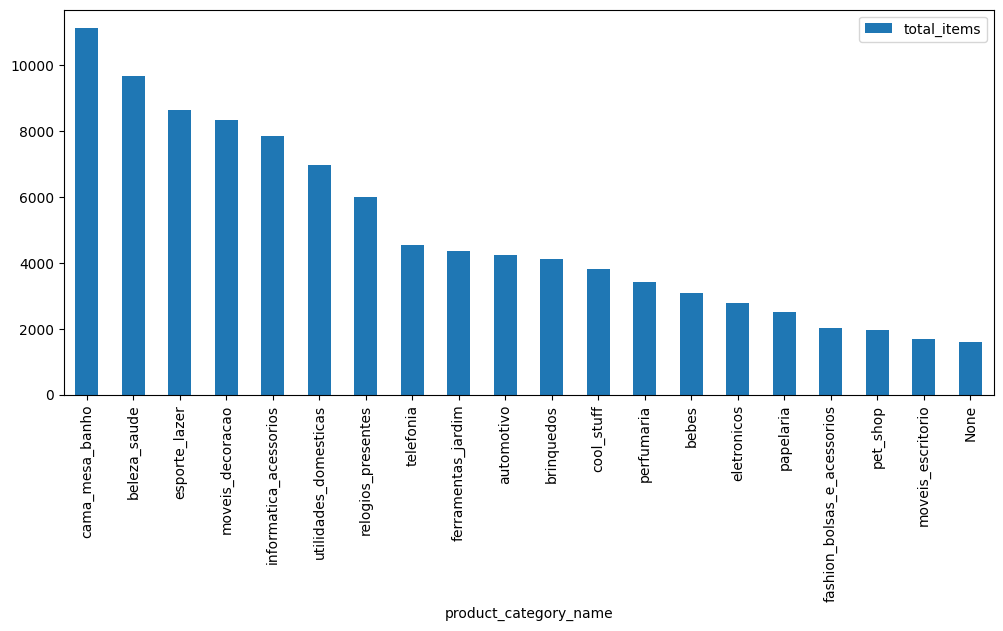

In [3]:
df_top_categories.plot(x="product_category_name", y="total_items", kind="bar", figsize=(12,5))